# Optional Lab: 模型表示

<figure>
 <img src="../work/images/C1_W1_L3_S1_Lecture_b.png"   style="width:600px;height:200px;">
</figure>

## 目标
在这个实验中你将：
- 学习实现单变量线性回归的模型 $f_{w,b}$。

## 符号说明
以下是你将会遇到的一些符号的总结。

|基本符号| 说明| Python中怎么表示 (如果适用的话) |
|------------|---------------|----------------------------------------|
| $a$ | 标量，非粗体                                                     ||
| $\mathbf{a}$ | 向量，粗体                                                  ||
| **回归** |         |    |     |
|  $\mathbf{x}$ | 训练样本特征值（在本实验中为面积（1000 平方英尺））  | `x_train` |   
|  $\mathbf{y}$  | 训练样本目标（在本实验中为价格（以千美元为单位））。  | `y_train` 
|  $x^{(i)}$, $y^{(i)}$ | $i_{th}$训练样本 | `x_i`, `y_i`|
| $m$ | 训练样本数量 | `m`|
|  $w$  |  参数：权重weight                                | `w`    |
|  $b$           |  参数：偏差bias                                           | `b`    |     
| $f_{w,b}(x^{(i)})$ | 在参数为$w$和$b$的情况下，模型在$x^{(i)}$处的评估结果为：$f_{w,b}(x^{(i)}) = wx^{(i)}+b$。即$w$乘以$x^{(i)}$再加上$b$。  | `f_wb` | 


## Tools
在这个实验室中，你将使用：
- NumPy，一个流行的科学计算库；
- Matplotlib，一个流行的绘图数据库。

In [23]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('./deeplearning.mplstyle')

# Problem Statement
<img align="left" src="../work/images/C1_W1_L3_S1_trainingdata.png"    style=" width:380px; padding: 10px;  " /> 

我们用这个例子来预测房价。

这个实验室将使用一个只有两个数据点的简单数据集 —— 一个 1000 平方英尺的房子以 30 万美元的价格出售，一个 2000 平方英尺的房子以 50 万美元的价格出售。这两个点将构成我们的数据或训练集。在这个实验室中，大小单位是 1000 平方英尺，价格单位是 1000 美元。

| Size (1000 sqft)     | Price (1000s of dollars) |
| -------------------| ------------------------ |
| 1.0               | 300                      |
| 2.0               | 500                      |

You would like to fit a linear regression model (shown above as the blue straight line) through these two points, so you can then predict price for other houses - say, a house with 1200 sqft.

你希望通过这两个点拟合一个线性回归模型（如上面所示的蓝色直线），这样你就可以预测其他房屋的价格——比如说，一个 1200 平方英尺的房屋。


请运行以下代码单元以创建你的`x_train`和`y_train`变量。数据存储在一维 NumPy 数组中。

In [24]:
# x_train is the input variable (size in 1000 square feet)
# y_train is the target (price in 1000s of dollars)
x_train = np.array([1.0, 2.0])
y_train = np.array([300.0, 500.0])
print(f"x_train = {x_train}")
print(f"y_train = {y_train}")

x_train = [1. 2.]
y_train = [300. 500.]


>注意：本课程在打印时将频繁使用 Python 的 “f 字符串” 输出格式，如这里所述。在生成输出时，花括号之间的内容将被求值。

### 训练样本数量 `m`
你将使用 `m` 表示训练样本的数量。NumPy 数组有一个 `.shape` 参数。`x_train.shape` 返回一个 Python 元组，每个维度对应一个条目。`x_train.shape [0]` 是数组的长度和样本数量，如下所示。

In [25]:
# m is the number of training examples
print(f"x_train.shape: {x_train.shape}")
m = x_train.shape[0]
print(f"Number of training examples is: {m}")

x_train.shape: (2,)
Number of training examples is: 2


也可以用Python `len()` 函数。

In [26]:
# m is the number of training examples
m = len(x_train)
print(f"Number of training examples is: {m}")

Number of training examples is: 2


### 训练样本 `x_i, y_i`

你将使用(x$^{(i)}$, y$^{(i)}$)来表示第$i$个训练样本。由于 Python 是从 0 开始索引的，所以(x$^{(0)}$, y$^{(0)}$)是(1.0, 300.0)，(x$^{(1)}$, y$^{(1)}$)是(2.0, 500.0)。

要在 NumPy 数组中访问一个值，可以使用所需的偏移量对数组进行索引。例如，访问`x_train`的位置零的语法是`x_train[0]`。<br/> 
运行下面的下一个代码块以获取第$i$个训练样本。

In [27]:
i = 0 # Change this to 1 to see (x^1, y^1)

x_i = x_train[i]
y_i = y_train[i]
print(f"(x^({i}), y^({i})) = ({x_i}, {y_i})")

(x^(0), y^(0)) = (1.0, 300.0)


### 绘制数据

您可以使用 `matplotlib` 库中的散射函数`scatter()`绘制这两个点，如下面的单元格所示。

- 函数参数标记`marker`和 `c` 将点显示为红叉（默认为蓝点）。


您可以使用 `matplotlib` 库中的其他函数来设置要显示的标题和标签


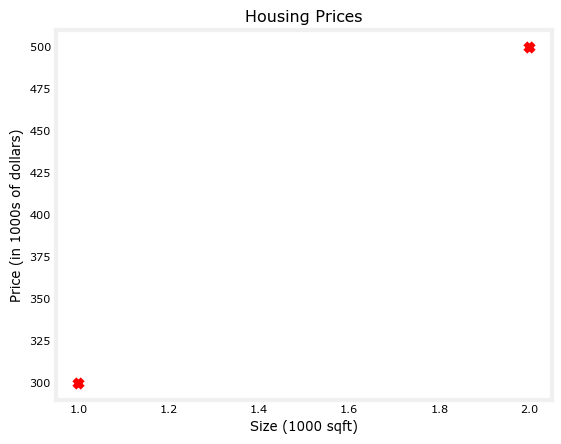

In [28]:
# Plot the data points
plt.scatter(x_train, y_train, marker='x', c='r')
# Set the title
plt.title("Housing Prices")
# Set the y-axis label
plt.ylabel('Price (in 1000s of dollars)')
# Set the x-axis label
plt.xlabel('Size (1000 sqft)')
plt.show()

## Model function

<img align="left" src="../work/images/C1_W1_L3_S1_model.png"     style=" width:380px; padding: 10px; " > 

如讲座中所述，线性回归的模型函数（即从`x`映射到`y`的函数）表示为

$$ f_{w,b}(x^{(i)}) = wx^{(i)} + b \tag{1}$$

上面的公式是你可以表示直线的方式 —— 不同的$w$ 和 $b$会在图上给出不同的直线。<br/>

让我们通过下面的代码块更好地理解这一点。让我们从$w = 100$ 和 $b = 100$开始。

**Note: You can come back to this cell to adjust the model's w and b parameters**
<br/> **注意：你可以回到这个单元格调整模型的 w 和 b 参数**

In [29]:
w = 22
b = 11
print(f"w: {w}")
print(f"b: {b}")

w: 22
b: 11


现在，让我们为你的两个数据点计算$f_{w,b}(x^{(i)})$的值。你可以针对每个数据点明确地写出如下内容。

for $x^{(0)}$, `f_wb = w * x[0] + b`

for $x^{(1)}$, `f_wb = w * x[1] + b`

对于大量的数据点，这可能会变得笨拙和重复。因此，你可以在一个`for`循环中计算函数输出，如下面的`compute_model_output`函数所示。


> **注意**: 参数描述`(ndarray (m,))`表示形状为 (m,) 的 NumPy n 维数组。`(scalar)`表示没有维度的参数，只有一个量级。<br/> 
> **注意**: `np.zero(n)`将返回一个具有 $n$ 个元素的一维 NumPy 数组。<br/> 


In [30]:
def compute_model_output(x, w, b):
    """
    Computes the prediction of a linear model
    Args:
      x (ndarray (m,)): Data, m examples 
      w,b (scalar)    : model parameters  
    Returns
      y (ndarray (m,)): target values
    """
    m = x.shape[0]
    f_wb = np.zeros(m)
    for i in range(m):
        f_wb[i] = w * x[i] + b
        
    return f_wb

现在让我们调用`compute_model_output`函数并绘制输出。

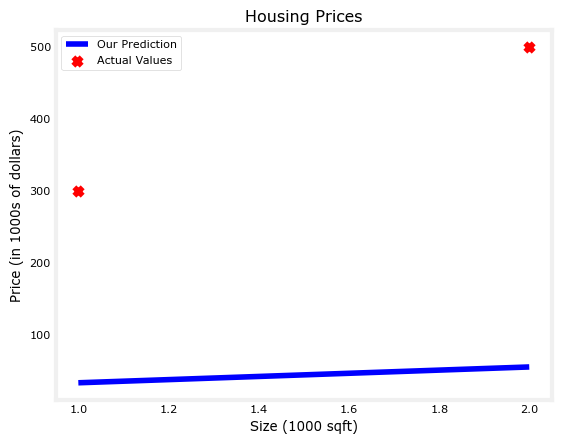

In [31]:
tmp_f_wb = compute_model_output(x_train, w, b,)

# Plot our model prediction
plt.plot(x_train, tmp_f_wb, c='b',label='Our Prediction')

# Plot the data points
plt.scatter(x_train, y_train, marker='x', c='r',label='Actual Values')

# Set the title
plt.title("Housing Prices")
# Set the y-axis label
plt.ylabel('Price (in 1000s of dollars)')
# Set the x-axis label
plt.xlabel('Size (1000 sqft)')
plt.legend()
plt.show()

如你所见，设置$w = 22$和$b = 11$并不能得到一条符合我们数据的直线。
### 挑战
尝试使用不同的$w$和$b$值。对于一条符合我们数据的直线，这些值应该是多少？
#### 提示:
你可以用鼠标点击下面绿色“提示”左边的三角形，以显示一些选择 b 和 w 的提示。

<details>
<summary>
    <font size='3', color='darkgreen'><b>提示</b></font>
</summary>
    <p>
    <ul>
        <li>Try $w = 200$ and $b = 100$ </li>
    </ul>
    </p>

### 预测
现在我们有了一个模型，就可以用它来进行我们最初的预测。让我们预测一下面积为 1200 平方英尺的房子的价格。由于$x$的单位是千平方英尺，所以$x$是 1.2。


In [32]:
w = 200                         
b = 100    
x_i = 1.2
cost_1200sqft = w * x_i + b    

print(f"${cost_1200sqft:.0f} thousand dollars")

$340 thousand dollars


# 恭喜！!
在这个实验室中你学到了：
- 线性回归建立一个模型，该模型在特征和目标之间建立关系。
    - 在上面的示例中，特征是房屋面积，目标是房屋价格。
    - 对于简单线性回归，模型有两个参数$w$和$b$，其值使用`训练数据`进行`拟合`。
    - 一旦确定了模型的参数，该模型就可以用于对新数据进行预测。